# Saving and Loading VISTA Results

Computing a high-resolution VISTA map can take a while. Once you have a result, you usually want to **persist** it — to share with colleagues, archive for a paper, or simply avoid re-running the computation. This notebook covers the full save/load round-trip:

* **CSV format** (default) — a `.csv` data file paired with a `.meta.json` metadata companion.
* **Legacy text format** — a compact single-row digit string used by earlier VISTA versions.
* A **batch workflow** that saves and reloads results for several methods at once.

In [1]:
%matplotlib inline

In [2]:
from mcda_vista import generate_vista, plot_vista, VistaResult
from mcda_vista.io import save_vista, load_vista, load_legacy_relations
import numpy as np
from pathlib import Path
import json, shutil

In [3]:
output_dir = Path("output_demo")
output_dir.mkdir(exist_ok=True)
print(f"Temporary output directory: {output_dir.resolve()}")

Temporary output directory: D:\Praca\Uczelnia\Praca naukowa\Github\mcda-vista\notebooks\output_demo


## 1. Generate a Result

We start with a standard TOPSIS VISTA map at `resolution=51` (fast enough for a demo).

Method:     topsis
Resolution: 51
Grid shape: (2601, 2)
Relations:  (2601,)  unique=[0 1 2 3]


C:\Users\dariu\AppData\Local\Temp\ipykernel_22452\763442323.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


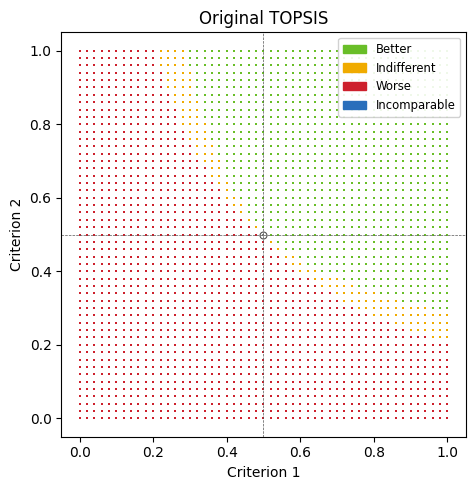

In [4]:
result = generate_vista("topsis", resolution=51, delta=0.10, progress=False)

print(f"Method:     {result.method_name}")
print(f"Resolution: {result.resolution}")
print(f"Grid shape: {result.grid.shape}")
print(f"Relations:  {result.relations.shape}  unique={np.unique(result.relations)}")

fig = plot_vista(result, title="Original TOPSIS")
fig.show()

## 2. Save to CSV

The default format writes **two files**:

| File | Contents |
|------|----------|
| `<name>.csv` | Grid coordinates + relation column |
| `<name>.meta.json` | Method name, resolution, reference, weights, params |

Pass a path **without** an extension — `save_vista` appends `.csv` and `.meta.json` automatically.

In [5]:
csv_path = save_vista(
    grid=result.grid,
    relations=result.relations,
    path=output_dir / "topsis_demo",
    reference=result.reference,
    weights=result.weights,
    method_name=result.method_name,
    params=result.params,
    resolution=result.resolution,
)
print(f"Saved to: {csv_path}")

Saved to: output_demo\topsis_demo.csv


In [6]:
# Files created in the output directory
for f in sorted(output_dir.iterdir()):
    print(f"  {f.name:30s}  ({f.stat().st_size:,} bytes)")

  topsis_demo.csv                 (54,637 bytes)
  topsis_demo.meta.json           (216 bytes)


In [7]:
# Peek at the CSV (first 5 data rows + header)
csv_file = output_dir / "topsis_demo.csv"
lines = csv_file.read_text().splitlines()
for line in lines[:6]:
    print(line)

x0,x1,relation
0.000000,0.000000,1
0.000000,0.020000,1
0.000000,0.040000,1
0.000000,0.060000,1
0.000000,0.080000,1


In [8]:
# Inspect the companion metadata
meta_file = output_dir / "topsis_demo.meta.json"
meta = json.loads(meta_file.read_text())
print(json.dumps(meta, indent=2))

{
  "method_name": "topsis",
  "resolution": 51,
  "n_criteria": 2,
  "n_points": 2601,
  "reference": [
    0.5,
    0.5
  ],
  "weights": [
    1.0,
    1.0
  ],
  "params": {
    "delta": 0.1
  }
}


## 3. Load from CSV

`load_vista` reads the `.csv` and its `.meta.json` companion, returning a plain dictionary.

In [9]:
loaded = load_vista(output_dir / "topsis_demo")

print("Keys:", list(loaded.keys()))
print(f"Grid shape:      {loaded['grid'].shape}")
print(f"Relations shape:  {loaded['relations'].shape}")
print(f"Method name:      {loaded['method_name']}")
print(f"Resolution:       {loaded['resolution']}")
print(f"Reference:        {loaded['reference']}")
print(f"Weights:          {loaded['weights']}")

Keys: ['grid', 'relations', 'method_name', 'params', 'resolution', 'reference', 'weights']
Grid shape:      (2601, 2)
Relations shape:  (2601,)
Method name:      topsis
Resolution:       51
Reference:        [0.5 0.5]
Weights:          [1. 1.]


C:\Users\dariu\AppData\Local\Temp\ipykernel_22452\372966073.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


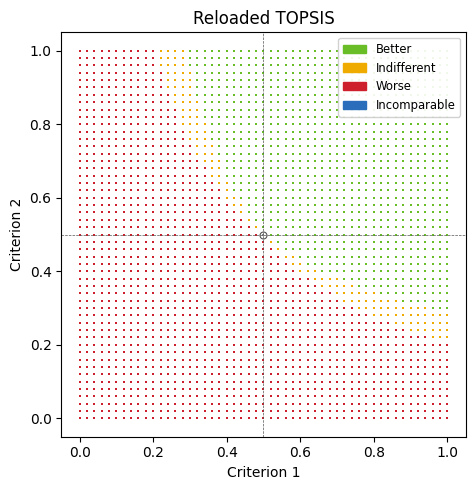

In [10]:
# Reconstruct a VistaResult so we can plot it
reloaded_result = VistaResult(
    grid=loaded["grid"],
    relations=loaded["relations"],
    reference=loaded["reference"],
    weights=loaded["weights"],
    method_name=loaded["method_name"],
    params=loaded["params"],
    resolution=loaded["resolution"],
    n_criteria=loaded["grid"].shape[1],
)

fig = plot_vista(reloaded_result, title="Reloaded TOPSIS")
fig.show()

In [11]:
# Verify the round-trip (grid uses approximate check due to CSV write precision)
assert np.allclose(result.grid, reloaded_result.grid), "Grid mismatch!"
assert np.array_equal(result.relations, reloaded_result.relations), "Relations mismatch!"
print("Round-trip verification passed — original and reloaded data match.")

Round-trip verification passed — original and reloaded data match.


## 4. Legacy Text Format

Earlier versions of VISTA stored relation values as a single row of digit codes (`1`/`2`/`3`/`4`) in a plain `.txt` file — no metadata, no grid coordinates. You can still export and import this format for backward compatibility.

In [12]:
legacy_path = save_vista(
    result.grid,
    result.relations,
    output_dir / "topsis_legacy.txt",
    format="legacy_txt",
)
print(f"Legacy file: {legacy_path}")
print(f"File size:   {legacy_path.stat().st_size:,} bytes")

Legacy file: output_demo\topsis_legacy.txt
File size:   2,601 bytes


In [13]:
# Show the first 200 characters — just a flat string of digit codes
content = legacy_path.read_text()
print(f"Total characters: {len(content)}")
print(f"First 200 chars:  {content[:200]}")

Total characters: 2601
First 200 chars:  11111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111


In [14]:
# Load legacy relations back
legacy_relations = load_legacy_relations(legacy_path, resolution=51)

print(f"Shape: {legacy_relations.shape}")
print(f"Unique values: {np.unique(legacy_relations)}")
assert np.array_equal(result.relations, legacy_relations), "Mismatch!"
print("Legacy round-trip OK.")

Shape: (2601,)
Unique values: [0 1 2 3]
Legacy round-trip OK.


> **Note:** The legacy format discards grid coordinates, reference, weights, and all other metadata. Use it only when interoperability with older scripts is required; prefer the CSV format for new work.

## 5. Batch Save / Load Workflow

A common scenario: generate VISTA maps for several methods, save them all, then reload and compare later.

In [15]:
methods = ["topsis", "saw", "vikor"]

# Generate and save
for name in methods:
    r = generate_vista(name, resolution=51, progress=False)
    save_vista(
        grid=r.grid,
        relations=r.relations,
        path=output_dir / name,
        reference=r.reference,
        weights=r.weights,
        method_name=r.method_name,
        params=r.params,
        resolution=r.resolution,
    )
    print(f"Saved {name}")

print("\nAll saved. Files on disk:")
for f in sorted(output_dir.iterdir()):
    print(f"  {f.name}")

Saved topsis


Saved saw


Saved vikor

All saved. Files on disk:
  saw.csv
  saw.meta.json
  topsis.csv
  topsis.meta.json
  topsis_demo.csv
  topsis_demo.meta.json
  topsis_legacy.txt
  vikor.csv
  vikor.meta.json


In [16]:
# Load all back and reconstruct VistaResult objects
reloaded_results = []
for name in methods:
    data = load_vista(output_dir / name)
    vr = VistaResult(
        grid=data["grid"],
        relations=data["relations"],
        reference=data["reference"],
        weights=data["weights"],
        method_name=data["method_name"],
        params=data["params"],
        resolution=data["resolution"],
        n_criteria=data["grid"].shape[1],
    )
    reloaded_results.append(vr)
    print(f"Loaded {data['method_name']} — grid {data['grid'].shape}")

print(f"\n{len(reloaded_results)} results ready for comparison.")

Loaded topsis — grid (2601, 2)
Loaded saw — grid (2601, 2)
Loaded vikor — grid (2601, 2)

3 results ready for comparison.


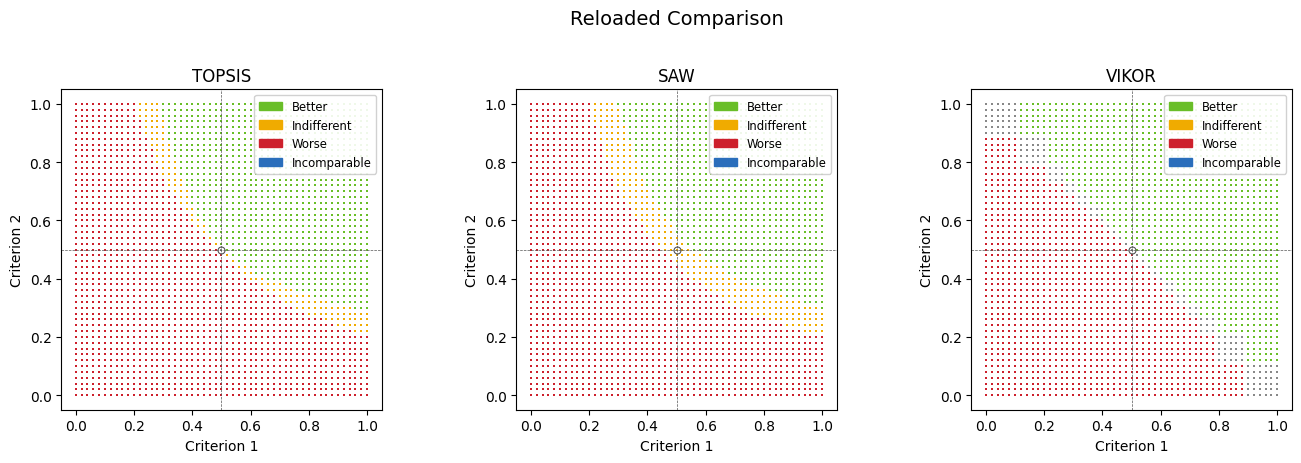

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, vr in zip(axes, reloaded_results):
    plot_vista(vr, ax=ax, title=vr.method_name.upper())
fig.suptitle("Reloaded Comparison", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 6. Cleanup

Remove the temporary output directory created by this notebook.

In [18]:
shutil.rmtree(output_dir)
print(f"Removed {output_dir}/")

Removed output_demo/


## Summary

| Task | Function | Format |
|------|----------|--------|
| Save (recommended) | `save_vista(..., format="csv")` | `.csv` + `.meta.json` |
| Load | `load_vista(path)` → `dict` | CSV |
| Save (legacy) | `save_vista(..., format="legacy_txt")` | single-row `.txt` |
| Load (legacy) | `load_legacy_relations(path, resolution)` → `np.ndarray` | single-row `.txt` |

**Key takeaways:**

* The **CSV format** preserves everything — grid, relations, reference, weights, method name, and parameters — so you can reconstruct a full `VistaResult` later.
* The **legacy text format** stores only the relation codes. Use it for backward compatibility with older VISTA scripts.
* Always verify a round-trip with `np.allclose` (floats) or `np.array_equal` (integers) when correctness matters.
* For batch workflows, loop over method names, save each result, and reload them later for comparison plots.